In [4]:
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

Download (or load if has already been downloaded) a TF dataset with Rock, Paper and Scissors images

In [ ]:
import tensorflow_datasets as tfds
ds, info = tfds.load('rock_paper_scissors', with_info=True, as_supervised=True)

AttributeError: 'dict' object has no attribute 'filter'

Visualise the image nº N of the train split

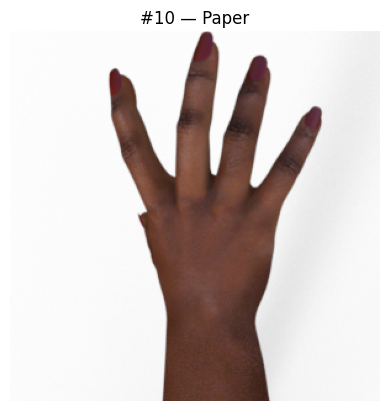

In [ ]:
N = 10
ds_train = ds['train']  # extraer el split
LABELS = ['Rock', 'Paper', 'Scissors']

image, label = next(iter(ds_train.skip(N).take(1)))
plt.imshow(image.numpy())
plt.title(f'#{N} — {LABELS[label.numpy()]}')
plt.axis('off')
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# ── Load & preprocess ──────────────────────────────────────────────
IMG_SIZE = (64, 64)
BATCH    = 32
EPOCHS   = 200  # High epochs, because we will use early stopping

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

ds = tfds.load('rock_paper_scissors', as_supervised=True)
train_ds = (ds['train']
            .map(preprocess)
            .map(augment)              # augmentation only in train
            .shuffle(1000)
            .batch(BATCH)
            .prefetch(tf.data.AUTOTUNE))
test_ds  = (ds['test']
            .map(preprocess)           # no augmentation on test
            .batch(BATCH)
            .prefetch(tf.data.AUTOTUNE))

# ── Build CNN ──────────────────────────────────────────────────────
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────────────
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,          # para si no mejora en 5 epochs seguidas
    restore_best_weights=True,
    verbose=1
)

# ── Train & save ───────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    callbacks=[early_stopping]
)
model.save('rps_model.keras')
print("Model saved")

# ── Plot training vs validation ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train accuracy')
ax1.plot(history.history['val_accuracy'], label='Val accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train loss')
ax2.plot(history.history['val_loss'], label='Val loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

# Marcar el epoch donde paró early stopping
stopped_epoch = early_stopping.stopped_epoch
if stopped_epoch > 0:
    best_epoch = stopped_epoch - early_stopping.patience
    ax1.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch+1})')
    ax2.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch+1})')
    ax1.legend()
    ax2.legend()

plt.suptitle('Training vs Validation', fontsize=14)
plt.tight_layout()
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,339 (4.36 MB)

 Trainable params: 1,142,339 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6536 - loss: 0.7257 - val_accuracy: 0.8414 - val_loss: 0.3345
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9881 - loss: 0.0538 - val_accuracy: 0.8817 - val_loss: 0.2372
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9917 - loss: 0.0296 - val_accuracy: 0.8548 - val_loss: 0.3447
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9976 - loss: 0.0109 - val_accuracy: 0.8683 - val_loss: 0.3387
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9976 - loss: 0.0084 - val_accuracy: 0.8387 - val_loss: 0.4970
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9960 - loss: 0.0095 - val_accuracy: 0.9059 - val_loss: 0.2097
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9964 - loss: 0.0125 - val_accuracy: 0.9086 - val_loss: 0.2990
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 0.9032 - v

Run the model on my laptop webcam

In [ ]:
import cv2
import numpy as np
import tensorflow as tf

# ── Load model ─────────────────────────────────────────────────────
model  = tf.keras.models.load_model('rps_model.keras')
LABELS = ['Rock', 'Paper', 'Scissors']
COLORS = {'Rock': (60,60,220), 'Paper': (40,180,40), 'Scissors': (0,180,220)}

# ── Webcam loop ────────────────────────────────────────────────────
cap = cv2.VideoCapture(0)
print("Press Q to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Define a Region of Interest (ROI) — the box where user puts their hand
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = w//2 - 100, 80, w//2 + 100, 280
    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 255, 255), 2)

    # Crop, resize, normalise
    roi = frame[y1:y2, x1:x2]
    roi_rgb   = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    roi_resized = cv2.resize(roi_rgb, (64, 64))
    roi_norm  = roi_resized.astype('float32') / 255.0
    input_tensor = np.expand_dims(roi_norm, axis=0)  # shape (1,64,64,3)

    # Predict
    preds = model.predict(input_tensor, verbose=0)[0]
    class_idx   = np.argmax(preds)
    label       = LABELS[class_idx]
    confidence  = preds[class_idx] * 100
    color       = COLORS[label]

    # Overlay result
    cv2.putText(frame, f'{label}  {confidence:.0f}%',
                (x1, y1 - 12), cv2.FONT_HERSHEY_SIMPLEX,
                0.9, color, 2)
    cv2.putText(frame, 'Place hand in box',
                (x1, y2 + 28), cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (200, 200, 200), 1)

    cv2.imshow('Rock Paper Scissors', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()